# Неделя 4 — неудачный эволюционный поиск признаков


Этот ноутбук сохранён как отрицательный эксперимент. Эволюционный поиск действительно нашёл конфигурацию с хорошим internal validation score, но выбранный best_safety candidate не улучшил official test относительно Week 3. Основная причина — validation-схема и fitness function переоценили слишком консервативную конфигурацию с capped RUL. Поэтому этот результат не используется как финальная модель, но сохраняется как важный методологический вывод: автоматический поиск признаков требует проверки нескольких top candidates, а не выбора одного лучшего кандидата только по internal validation.

## 1. Идея недели

На третьей неделе мы получили сильный практический baseline: RandomForest на агрегатных признаках с консервативной калибровкой. Однако набор агрегатных признаков был выбран вручную: часть признаков считалась обязательной, а часть перебиралась ограниченно.

На четвёртой неделе мы рассматриваем построение признаков как задачу оптимизации. Вместо ручного перебора запускается эволюционный поиск. Каждый кандидат кодирует:

- какие блоки агрегатных признаков использовать;
- какой размер окна брать;
- использовать ли capped RUL;
- какие параметры RandomForest выбрать.

После того как найден лучший pipeline, отдельно подбирается conservative shift. Это важно методологически: сначала выбираем модель и признаки, затем калибруем уже готовые предсказания.

Главная идея: shift не подбирается во время поиска модели. Сначала находится лучшая конфигурация признаков и RandomForest на внутренней валидации, затем для уже выбранной модели отдельно подбирается консервативная постобработка.

## 2. Импорты и конфигурация

In [14]:
import os
import json
import time
import random
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

random_state = 42
np.random.seed(random_state)
random.seed(random_state)

DATA_DIR = Path("CMAPSSData")
OUTPUT_DIR = Path("outputs")
CACHE_DIR = OUTPUT_DIR / "week4_cache"
OUTPUT_DIR.mkdir(exist_ok=True)
CACHE_DIR.mkdir(exist_ok=True)

USE_CACHE = True
RUN_OFFICIAL_TEST_AT_END = True
FAST_MODE = False
PROGRESS_EVERY_CANDIDATE = True
PROGRESS_FLUSH = True

population_size = 18
generations = 8
elite_size = 4
tournament_size = 4
mutation_rate = 0.18
crossover_rate = 0.75
random_injection_rate = 0.15
early_stop_generations = 3
min_feature_blocks = 4
max_feature_blocks = 14
validation_seed = 42

search_rf_base = {
    "n_estimators": 180,
    "random_state": 42,
    "n_jobs": -1,
}

final_rf_base = {
    "n_estimators": 400,
    "random_state": 42,
    "n_jobs": -1,
}

if FAST_MODE:
    population_size = 8
    generations = 3
    search_rf_base["n_estimators"] = 80

columns = [
    "unit_id", "cycle", "op_setting_1", "op_setting_2", "op_setting_3",
    "sensor_1", "sensor_2", "sensor_3", "sensor_4", "sensor_5",
    "sensor_6", "sensor_7", "sensor_8", "sensor_9", "sensor_10",
    "sensor_11", "sensor_12", "sensor_13", "sensor_14", "sensor_15",
    "sensor_16", "sensor_17", "sensor_18", "sensor_19", "sensor_20", "sensor_21",
]

target_col = "Remaining Useful Life"
eps = 1e-6


## 3. Загрузка данных

Используем FD001 и ту же постановку RUL, что в предыдущих неделях: для train RUL равен `max_cycle_per_unit - cycle`, а для official test берётся последняя доступная строка каждого двигателя и истинный RUL из `RUL_FD001.txt`.

In [ ]:
def load_cmapss_fd001(data_dir):
    train_df = pd.read_csv(data_dir / "train_FD001.txt", sep=r"\s+", header=None, names=columns)
    test_df = pd.read_csv(data_dir / "test_FD001.txt", sep=r"\s+", header=None, names=columns)
    rul_test_df = pd.read_csv(data_dir / "RUL_FD001.txt", sep=r"\s+", header=None, names=["RUL"])
    return train_df, test_df, rul_test_df


def add_rul_target(train_df):
    train_df = train_df.copy()
    max_cycle = train_df.groupby("unit_id")["cycle"].max()
    train_df[target_col] = train_df["unit_id"].map(max_cycle) - train_df["cycle"]
    return train_df


train_df, test_df, rul_test_df = load_cmapss_fd001(DATA_DIR)
train_df = add_rul_target(train_df)
y_test_official = rul_test_df["RUL"].reset_index(drop=True)
feature_source_cols = [col for col in train_df.columns if col.startswith("op_setting_") or col.startswith("sensor_")]

pd.DataFrame({
    "dataset": ["train_FD001", "test_FD001", "RUL_FD001"],
    "rows": [len(train_df), len(test_df), len(rul_test_df)],
    "columns": [train_df.shape[1], test_df.shape[1], rul_test_df.shape[1]],
})


## 4. Внутреннее validation-разбиение по двигателям

Официальный test set не используется для выбора признаков. Сначала train_FD001 делится по `unit_id`: 80% двигателей используются для обучения поиска, 20% — для внутренней валидации.

Для валидационных двигателей имитируется test-постановка: для каждого двигателя создаются несколько cutoff-точек жизненного цикла, а признаки строятся только по истории до выбранного cutoff.

In [ ]:
def split_train_valid_units(train_df, valid_share=0.2, seed=42):
    unit_ids = np.array(sorted(train_df["unit_id"].unique()))
    rng = np.random.default_rng(seed)
    shuffled = unit_ids.copy()
    rng.shuffle(shuffled)
    valid_count = max(1, int(round(len(shuffled) * valid_share)))
    valid_units = set(shuffled[:valid_count])
    train_units = set(shuffled[valid_count:])
    train_search_df = train_df[train_df["unit_id"].isin(train_units)].copy().reset_index(drop=True)
    valid_search_df = train_df[train_df["unit_id"].isin(valid_units)].copy().reset_index(drop=True)
    return train_search_df, valid_search_df, sorted(train_units), sorted(valid_units)


def make_validation_cutoffs(valid_df, cutoff_fractions=[0.5, 0.7, 0.85, 0.95, 1.0]):
    rows = []
    for unit_id, unit_df in valid_df.groupby("unit_id"):
        max_cycle = int(unit_df["cycle"].max())
        for fraction in cutoff_fractions:
            cutoff_cycle = int(np.floor(max_cycle * fraction))
            cutoff_cycle = min(max(cutoff_cycle, 1), max_cycle)
            rows.append({
                "unit_id": unit_id,
                "cutoff_cycle": cutoff_cycle,
                "true_rul": max_cycle - cutoff_cycle,
            })
    return pd.DataFrame(rows).drop_duplicates(["unit_id", "cutoff_cycle"]).reset_index(drop=True)


train_search_df, valid_search_df, train_units, valid_units = split_train_valid_units(train_df, seed=validation_seed)
validation_cutoffs_df = make_validation_cutoffs(valid_search_df)

pd.DataFrame({
    "split": ["train_search", "valid_search", "validation_cutoffs"],
    "units": [len(train_units), len(valid_units), validation_cutoffs_df["unit_id"].nunique()],
    "rows": [len(train_search_df), len(valid_search_df), len(validation_cutoffs_df)],
})


## 5. Пространство агрегатных блоков признаков

Каждый кандидат выбирает подмножество блоков агрегатных признаков. Блоки построены вокруг того же семейства признаков, которое использовалось в третьей неделе: rolling-статистики, тренды, изменения, относительные изменения и устойчивые меры разброса.

In [17]:
all_feature_blocks = [
    "mean", "std", "min", "max", "range", "delta", "slope", "last_minus_mean",
    "median", "iqr", "first", "last", "relative_delta", "relative_last_minus_mean",
    "rms", "edge_means", "slope_change", "tail_quantiles", "robust_spread", "volatility",
]

def calculate_slope(values):
    values = np.asarray(values, dtype=float)
    if len(values) <= 1:
        return 0.0
    x = np.arange(len(values), dtype=float)
    x = x - x.mean()
    denominator = np.sum(x ** 2)
    if denominator == 0:
        return 0.0
    return float(np.dot(values, x) / denominator)


def calculate_rms(values):
    values = np.asarray(values, dtype=float)
    return float(np.sqrt(np.mean(values ** 2))) if len(values) else 0.0


def calculate_slope_change(values):
    values = np.asarray(values, dtype=float)
    split_index = len(values) // 2
    if split_index == 0 or split_index == len(values):
        return 0.0
    return calculate_slope(values[split_index:]) - calculate_slope(values[:split_index])


def calculate_volatility(values):
    values = np.asarray(values, dtype=float)
    if len(values) <= 1:
        return 0.0
    return float(np.mean(np.abs(np.diff(values))))


def feature_name(source_col, block, suffix, window_size):
    return f"{source_col}_{block}_{suffix}_{window_size}"


In [18]:
def make_block_frame(base_df, block_name, block_values, window_size):
    if isinstance(block_values, dict):
        frames = []
        columns = []
        for suffix, values in block_values.items():
            frame = values.copy()
            frame.columns = [feature_name(col, block_name, suffix, window_size) for col in frame.columns]
            columns.extend(frame.columns)
            frames.append(frame)
        return pd.concat(frames, axis=1), columns
    frame = block_values.copy()
    frame.columns = [feature_name(col, block_name, "value", window_size) for col in frame.columns]
    return frame, list(frame.columns)


def build_rolling_feature_blocks(sorted_df, config, require_full_window):
    window_size = config["window_size"]
    selected_blocks = config["selected_blocks"]
    edge_window_size = max(1, min(10, window_size // 3))
    min_periods = window_size if require_full_window else 1
    edge_min_periods = edge_window_size if require_full_window else 1
    rolling = sorted_df.groupby("unit_id")[feature_source_cols].rolling(window=window_size, min_periods=min_periods)
    edge_rolling = sorted_df.groupby("unit_id")[feature_source_cols].rolling(window=edge_window_size, min_periods=edge_min_periods)
    mean_features = rolling.mean().reset_index(level=0, drop=True)
    std_features = rolling.std(ddof=0).reset_index(level=0, drop=True).fillna(0)
    min_features = rolling.min().reset_index(level=0, drop=True)
    max_features = rolling.max().reset_index(level=0, drop=True)
    median_features = rolling.median().reset_index(level=0, drop=True)
    q10_features = rolling.quantile(0.10).reset_index(level=0, drop=True)
    q25_features = rolling.quantile(0.25).reset_index(level=0, drop=True)
    q75_features = rolling.quantile(0.75).reset_index(level=0, drop=True)
    q90_features = rolling.quantile(0.90).reset_index(level=0, drop=True)
    first_features = sorted_df.groupby("unit_id")[feature_source_cols].shift(window_size - 1)
    if not require_full_window:
        first_values = sorted_df.groupby("unit_id")[feature_source_cols].transform("first")
        first_features = first_features.fillna(first_values)
    last_features = sorted_df[feature_source_cols]
    delta_features = last_features - first_features
    last_minus_mean_features = last_features - mean_features
    block_values = {
        "mean": mean_features,
        "std": std_features,
        "min": min_features,
        "max": max_features,
        "range": max_features - min_features,
        "delta": delta_features,
        "slope": rolling.apply(calculate_slope, raw=True).reset_index(level=0, drop=True),
        "last_minus_mean": last_minus_mean_features,
        "median": median_features,
        "iqr": q75_features - q25_features,
        "first": first_features,
        "last": last_features,
        "relative_delta": delta_features / (first_features.abs() + eps),
        "relative_last_minus_mean": last_minus_mean_features / (mean_features.abs() + eps),
        "rms": rolling.apply(calculate_rms, raw=True).reset_index(level=0, drop=True),
        "edge_means": {
            "first_edge": rolling.apply(lambda values: np.mean(values[:edge_window_size]), raw=True).reset_index(level=0, drop=True),
            "last_edge": edge_rolling.mean().reset_index(level=0, drop=True),
        },
        "slope_change": rolling.apply(calculate_slope_change, raw=True).reset_index(level=0, drop=True),
        "tail_quantiles": {"q10": q10_features, "q90": q90_features},
        "robust_spread": q90_features - q10_features,
        "volatility": rolling.apply(calculate_volatility, raw=True).reset_index(level=0, drop=True),
    }
    frames = []
    columns_by_block = {}
    for block_name in selected_blocks:
        frame, columns = make_block_frame(sorted_df, block_name, block_values[block_name], window_size)
        frames.append(frame)
        columns_by_block[block_name] = columns
    return pd.concat(frames, axis=1), columns_by_block


In [ ]:
def expected_feature_columns(config):
    window_size = config["window_size"]
    suffixes_by_block = {
        "edge_means": ["first_edge", "last_edge"],
        "tail_quantiles": ["q10", "q90"],
    }
    columns = []
    for block_name in config["selected_blocks"]:
        suffixes = suffixes_by_block.get(block_name, ["value"])
        for suffix in suffixes:
            for source_col in feature_source_cols:
                columns.append(feature_name(source_col, block_name, suffix, window_size))
    return columns


def single_history_feature_row(history_df, config):
    window_size = config["window_size"]
    selected_blocks = config["selected_blocks"]
    edge_window_size = max(1, min(10, window_size // 3))
    window_df = history_df.sort_values("cycle").tail(window_size)
    if len(window_df) == 0:
        raise ValueError("История для validation cutoff пустая")
    row = {}
    for col in feature_source_cols:
        values = window_df[col].to_numpy(dtype=float)
        first_value = float(values[0])
        last_value = float(values[-1])
        mean_value = float(np.mean(values))
        min_value = float(np.min(values))
        max_value = float(np.max(values))
        q10_value = float(np.quantile(values, 0.10))
        q25_value = float(np.quantile(values, 0.25))
        q75_value = float(np.quantile(values, 0.75))
        q90_value = float(np.quantile(values, 0.90))
        values_by_block = {
            "mean": [("value", mean_value)],
            "std": [("value", float(np.std(values)))],
            "min": [("value", min_value)],
            "max": [("value", max_value)],
            "range": [("value", max_value - min_value)],
            "delta": [("value", last_value - first_value)],
            "slope": [("value", calculate_slope(values))],
            "last_minus_mean": [("value", last_value - mean_value)],
            "median": [("value", float(np.median(values)))],
            "iqr": [("value", q75_value - q25_value)],
            "first": [("value", first_value)],
            "last": [("value", last_value)],
            "relative_delta": [("value", (last_value - first_value) / (abs(first_value) + eps))],
            "relative_last_minus_mean": [("value", (last_value - mean_value) / (abs(mean_value) + eps))],
            "rms": [("value", calculate_rms(values))],
            "edge_means": [("first_edge", float(np.mean(values[:edge_window_size]))), ("last_edge", float(np.mean(values[-edge_window_size:])))],
            "slope_change": [("value", calculate_slope_change(values))],
            "tail_quantiles": [("q10", q10_value), ("q90", q90_value)],
            "robust_spread": [("value", q90_value - q10_value)],
            "volatility": [("value", calculate_volatility(values))],
        }
        for block_name in selected_blocks:
            for suffix, value in values_by_block[block_name]:
                row[feature_name(col, block_name, suffix, window_size)] = value
    return row


def build_aggregated_features_for_units(df, config, mode, validation_cutoffs=None):
    if mode == "train":
        sorted_df = df.sort_values(["unit_id", "cycle"]).reset_index(drop=True)
        feature_frame, columns_by_block = build_rolling_feature_blocks(sorted_df, config, require_full_window=True)
        result_df = pd.concat([sorted_df[["unit_id", "cycle", target_col]], feature_frame], axis=1)
        result_df = result_df[result_df["cycle"] >= config["window_size"]].dropna().reset_index(drop=True)
        expected_columns = expected_feature_columns(config)
        missing_columns = [column for column in expected_columns if column not in result_df.columns]
        if missing_columns:
            raise ValueError(f"Не найдены train-признаки: {missing_columns[:5]}")
        X = result_df[expected_columns]
        y = result_df[target_col].reset_index(drop=True)
        if config["rul_cap"] is not None:
            y = y.clip(upper=config["rul_cap"])
        return X, y, result_df[["unit_id", "cycle"]]
    if mode == "official_test":
        sorted_df = df.sort_values(["unit_id", "cycle"]).reset_index(drop=True)
        feature_frame, columns_by_block = build_rolling_feature_blocks(sorted_df, config, require_full_window=False)
        result_df = pd.concat([sorted_df[["unit_id", "cycle"]], feature_frame], axis=1).dropna().reset_index(drop=True)
        last_rows = result_df.sort_values(["unit_id", "cycle"]).groupby("unit_id").tail(1).sort_values("unit_id").reset_index(drop=True)
        expected_columns = expected_feature_columns(config)
        missing_columns = [column for column in expected_columns if column not in last_rows.columns]
        if missing_columns:
            raise ValueError(f"Не найдены official test-признаки: {missing_columns[:5]}")
        X = last_rows[expected_columns]
        unit_ids = last_rows["unit_id"].reset_index(drop=True)
        return X, unit_ids
    if mode == "validation_cutoff":
        rows = []
        y_values = []
        validation_ids = []
        grouped = {unit_id: unit_df.sort_values("cycle") for unit_id, unit_df in df.groupby("unit_id")}
        for validation_row in validation_cutoffs.itertuples(index=False):
            history_df = grouped[validation_row.unit_id]
            history_df = history_df[history_df["cycle"] <= validation_row.cutoff_cycle]
            rows.append(single_history_feature_row(history_df, config))
            y_values.append(validation_row.true_rul)
            validation_ids.append(f"{validation_row.unit_id}_{validation_row.cutoff_cycle}")
        expected_columns = expected_feature_columns(config)
        X = pd.DataFrame(rows).reindex(columns=expected_columns)
        if X.isna().any().any():
            nan_columns = X.columns[X.isna().any()].tolist()
            raise ValueError(f"Validation-признаки содержат NaN: {nan_columns[:5]}")
        return X, pd.Series(y_values), pd.Series(validation_ids)
    raise ValueError(f"Unknown mode: {mode}")


## 6. Геном кандидата

Кандидат задаётся словарём: набор блоков признаков, размер окна, capped RUL и параметры RandomForest. Conservative shift намеренно не входит в геном: он подбирается только после выбора модели.

In [20]:
window_size_options = [30, 40, 50, 60, 80, 100]
rul_cap_options = [None, 100, 110, 120, 125, 130, 150]
rf_max_depth_options = [12, 16, 20, 24, None]
rf_min_samples_leaf_options = [1, 2, 3, 4, 5]
rf_min_samples_split_options = [2, 4, 5, 8, 10]
rf_max_features_options = ["sqrt", 0.4, 0.6, 0.8, None]
default_useful_blocks = ["mean", "std", "delta", "slope", "last_minus_mean", "median", "iqr"]


def stable_candidate(candidate):
    return {
        "selected_blocks": sorted(candidate["selected_blocks"]),
        "window_size": candidate["window_size"],
        "rul_cap": candidate["rul_cap"],
        "rf_max_depth": candidate["rf_max_depth"],
        "rf_min_samples_leaf": candidate["rf_min_samples_leaf"],
        "rf_min_samples_split": candidate["rf_min_samples_split"],
        "rf_max_features": candidate["rf_max_features"],
    }


def candidate_hash(candidate):
    payload = json.dumps(stable_candidate(candidate), sort_keys=True, ensure_ascii=False)
    return hashlib.md5(payload.encode("utf-8")).hexdigest()


def repair_candidate(candidate):
    candidate = candidate.copy()
    blocks = list(dict.fromkeys(candidate["selected_blocks"]))
    blocks = [block for block in blocks if block in all_feature_blocks]
    while len(blocks) < min_feature_blocks:
        block = random.choice(default_useful_blocks)
        if block not in blocks:
            blocks.append(block)
    if len(blocks) > max_feature_blocks:
        blocks = random.sample(blocks, max_feature_blocks)
    if not any(block in blocks for block in ["mean", "last", "median", "first"]):
        blocks.append("mean")
    if not any(block in blocks for block in ["std", "range", "iqr", "robust_spread", "volatility"]):
        blocks.append("std")
    if not any(block in blocks for block in ["delta", "slope", "last_minus_mean", "slope_change", "relative_delta"]):
        blocks.append("delta")
    candidate["selected_blocks"] = sorted(list(dict.fromkeys(blocks)))[:max_feature_blocks]
    return candidate


def random_candidate():
    block_count = random.randint(min_feature_blocks, max_feature_blocks)
    candidate = {
        "selected_blocks": random.sample(all_feature_blocks, block_count),
        "window_size": random.choice(window_size_options),
        "rul_cap": random.choice(rul_cap_options),
        "rf_max_depth": random.choice(rf_max_depth_options),
        "rf_min_samples_leaf": random.choice(rf_min_samples_leaf_options),
        "rf_min_samples_split": random.choice(rf_min_samples_split_options),
        "rf_max_features": random.choice(rf_max_features_options),
    }
    return repair_candidate(candidate)


week3_seed_candidate = repair_candidate({
    "selected_blocks": ["mean", "std", "min", "max", "range", "delta", "slope", "last_minus_mean", "edge_means", "rms", "slope_change", "first", "last", "median", "iqr", "relative_delta", "relative_last_minus_mean"],
    "window_size": 50,
    "rul_cap": None,
    "rf_max_depth": 20,
    "rf_min_samples_leaf": 3,
    "rf_min_samples_split": 5,
    "rf_max_features": None,
})


## 7. Fitness-функция

Оценка кандидата идёт только на внутренней валидации. Fitness построен не только вокруг MAE: в него входят доля завышений, ошибка near-failure зоны, ошибка warning-zone, максимальное завышение и размер признакового пространства.

In [21]:
def build_rf_params(candidate, base_params):
    params = base_params.copy()
    params.update({
        "max_depth": candidate["rf_max_depth"],
        "min_samples_leaf": candidate["rf_min_samples_leaf"],
        "min_samples_split": candidate["rf_min_samples_split"],
        "max_features": candidate["rf_max_features"],
    })
    return params


def build_error_table(y_true, y_pred, model_name, ids=None):
    if ids is None:
        ids = np.arange(len(y_true))
    error_df = pd.DataFrame({"model_name": model_name, "id": ids, "true_rul": np.asarray(y_true), "pred_rul": np.asarray(y_pred)})
    error_df["error"] = error_df["pred_rul"] - error_df["true_rul"]
    error_df["abs_error"] = error_df["error"].abs()
    return error_df


def zone_metrics(error_df, zone_name):
    if zone_name == "near_failure":
        subset = error_df[error_df["true_rul"] <= 30]
    elif zone_name == "warning_zone":
        subset = error_df[(error_df["true_rul"] > 30) & (error_df["true_rul"] <= 70)]
    elif zone_name == "mid_life":
        subset = error_df[(error_df["true_rul"] > 70) & (error_df["true_rul"] <= 120)]
    else:
        subset = error_df[error_df["true_rul"] > 120]
    if len(subset) == 0:
        return {"MAE": np.nan, "overestimation_share": np.nan}
    return {"MAE": mean_absolute_error(subset["true_rul"], subset["pred_rul"]), "overestimation_share": float((subset["error"] > 0).mean())}


def regression_metrics_from_error(error_df):
    over_errors = error_df.loc[error_df["error"] > 0, "error"]
    near = zone_metrics(error_df, "near_failure")
    warning = zone_metrics(error_df, "warning_zone")
    return {
        "MAE": mean_absolute_error(error_df["true_rul"], error_df["pred_rul"]),
        "RMSE": mean_squared_error(error_df["true_rul"], error_df["pred_rul"]) ** 0.5,
        "R2": r2_score(error_df["true_rul"], error_df["pred_rul"]),
        "mean_error": float(error_df["error"].mean()),
        "overestimation_share": float((error_df["error"] > 0).mean()),
        "max_overestimation": float(over_errors.max()) if len(over_errors) else 0.0,
        "near_failure_MAE": near["MAE"],
        "near_failure_overestimation_share": near["overestimation_share"],
        "warning_zone_MAE": warning["MAE"],
        "warning_zone_overestimation_share": warning["overestimation_share"],
    }


def compute_fitness(metrics):
    near_mae = metrics["near_failure_MAE"] if not pd.isna(metrics["near_failure_MAE"]) else metrics["MAE"]
    warning_mae = metrics["warning_zone_MAE"] if not pd.isna(metrics["warning_zone_MAE"]) else metrics["MAE"]
    return metrics["MAE"] + 4.0 * metrics["overestimation_share"] + 0.08 * near_mae + 0.04 * warning_mae + 0.03 * metrics["max_overestimation"] + 0.0005 * metrics["feature_count"]


In [22]:
evaluated_candidate_rows = []


def short_candidate_description(candidate):
    return f"window={candidate['window_size']} cap={candidate['rul_cap']} blocks={len(candidate['selected_blocks'])} depth={candidate['rf_max_depth']} leaf={candidate['rf_min_samples_leaf']} split={candidate['rf_min_samples_split']} max_features={candidate['rf_max_features']}"


def evaluate_candidate(candidate, progress_label=None):
    candidate = repair_candidate(candidate)
    hash_value = candidate_hash(candidate)
    cache_path = CACHE_DIR / f"{hash_value}.json"
    if progress_label and PROGRESS_EVERY_CANDIDATE:
        print(f"{progress_label} start {short_candidate_description(candidate)} hash={hash_value[:8]}", flush=PROGRESS_FLUSH)
    if USE_CACHE and cache_path.exists():
        with open(cache_path, "r", encoding="utf-8") as file:
            row = json.load(file)
        row["from_cache"] = True
        evaluated_candidate_rows.append(row)
        if progress_label and PROGRESS_EVERY_CANDIDATE:
            print(f"{progress_label} cache fitness={row['fitness']:.4f} MAE={row['MAE']:.4f} over={row['overestimation_share']:.4f}", flush=PROGRESS_FLUSH)
        return row
    try:
        start = time.perf_counter()
        X_train_candidate, y_train_candidate, train_meta = build_aggregated_features_for_units(train_search_df, candidate, mode="train")
        X_valid_candidate, y_valid_candidate, validation_ids = build_aggregated_features_for_units(valid_search_df, candidate, mode="validation_cutoff", validation_cutoffs=validation_cutoffs_df)
        model = RandomForestRegressor(**build_rf_params(candidate, search_rf_base))
        model.fit(X_train_candidate, y_train_candidate)
        pred_valid = model.predict(X_valid_candidate)
        train_seconds = time.perf_counter() - start
        error_df = build_error_table(y_valid_candidate, pred_valid, "validation", validation_ids)
        metrics = regression_metrics_from_error(error_df)
        metrics["feature_count"] = int(X_train_candidate.shape[1])
        metrics["train_seconds"] = float(train_seconds)
        metrics["fitness"] = float(compute_fitness(metrics))
        row = {**stable_candidate(candidate), **metrics, "candidate_hash": hash_value, "status": "ok", "from_cache": False}
        if progress_label and PROGRESS_EVERY_CANDIDATE:
            print(f"{progress_label} done fitness={row['fitness']:.4f} MAE={row['MAE']:.4f} over={row['overestimation_share']:.4f} near_MAE={row['near_failure_MAE']:.4f} sec={row['train_seconds']:.2f}", flush=PROGRESS_FLUSH)
    except Exception as exc:
        row = {**stable_candidate(candidate), "candidate_hash": hash_value, "fitness": 1e9, "MAE": np.nan, "RMSE": np.nan, "R2": np.nan, "mean_error": np.nan, "overestimation_share": np.nan, "max_overestimation": np.nan, "near_failure_MAE": np.nan, "near_failure_overestimation_share": np.nan, "warning_zone_MAE": np.nan, "warning_zone_overestimation_share": np.nan, "feature_count": np.nan, "train_seconds": np.nan, "status": str(exc), "from_cache": False}
        if progress_label and PROGRESS_EVERY_CANDIDATE:
            print(f"{progress_label} failed status={row['status']}", flush=PROGRESS_FLUSH)
    with open(cache_path, "w", encoding="utf-8") as file:
        json.dump(row, file, ensure_ascii=False, indent=2)
    evaluated_candidate_rows.append(row)
    return row


## 8. Кэширование кандидатов

Каждая конфигурация получает стабильный hash. Если кандидат уже был посчитан, его метрики загружаются из `outputs/week4_cache/`, а не пересчитываются заново. Это особенно важно для эволюционного поиска, где одинаковые кандидаты могут появляться повторно.

In [ ]:
pd.DataFrame({
    "cache_enabled": [USE_CACHE],
    "cache_dir": [str(CACHE_DIR)],
    "fast_mode": [FAST_MODE],
    "population_size": [population_size],
    "generations": [generations],
    "search_estimators": [search_rf_base["n_estimators"]],
})


## 9. Эволюционный алгоритм

Поиск не является grid search. Популяция кандидатов оценивается, лучшие конфигурации сохраняются, затем родители выбираются tournament selection, скрещиваются и мутируют. Дополнительно добавляется небольшая доля случайных кандидатов, чтобы сохранять разнообразие.

In [24]:
def mutate_candidate(candidate):
    mutated = {**candidate, "selected_blocks": list(candidate["selected_blocks"])}
    if random.random() < mutation_rate:
        action = random.choice(["add", "remove", "flip"])
        if action == "add":
            block = random.choice(all_feature_blocks)
            if block not in mutated["selected_blocks"]:
                mutated["selected_blocks"].append(block)
        elif action == "remove" and len(mutated["selected_blocks"]) > min_feature_blocks:
            mutated["selected_blocks"].remove(random.choice(mutated["selected_blocks"]))
        else:
            block = random.choice(all_feature_blocks)
            if block in mutated["selected_blocks"]:
                mutated["selected_blocks"].remove(block)
            else:
                mutated["selected_blocks"].append(block)
    if random.random() < mutation_rate:
        mutated["window_size"] = random.choice(window_size_options)
    if random.random() < mutation_rate:
        mutated["rul_cap"] = random.choice(rul_cap_options)
    if random.random() < mutation_rate:
        field = random.choice(["rf_max_depth", "rf_min_samples_leaf", "rf_min_samples_split", "rf_max_features"])
        options = {
            "rf_max_depth": rf_max_depth_options,
            "rf_min_samples_leaf": rf_min_samples_leaf_options,
            "rf_min_samples_split": rf_min_samples_split_options,
            "rf_max_features": rf_max_features_options,
        }[field]
        mutated[field] = random.choice(options)
    return repair_candidate(mutated)


def crossover_candidates(parent_a, parent_b):
    if random.random() > crossover_rate:
        return repair_candidate(parent_a.copy())
    blocks = []
    for block in all_feature_blocks:
        if block in parent_a["selected_blocks"] and block in parent_b["selected_blocks"]:
            if random.random() < 0.85:
                blocks.append(block)
        elif block in parent_a["selected_blocks"] or block in parent_b["selected_blocks"]:
            if random.random() < 0.5:
                blocks.append(block)
    child = {
        "selected_blocks": blocks,
        "window_size": random.choice([parent_a["window_size"], parent_b["window_size"]]),
        "rul_cap": random.choice([parent_a["rul_cap"], parent_b["rul_cap"]]),
        "rf_max_depth": random.choice([parent_a["rf_max_depth"], parent_b["rf_max_depth"]]),
        "rf_min_samples_leaf": random.choice([parent_a["rf_min_samples_leaf"], parent_b["rf_min_samples_leaf"]]),
        "rf_min_samples_split": random.choice([parent_a["rf_min_samples_split"], parent_b["rf_min_samples_split"]]),
        "rf_max_features": random.choice([parent_a["rf_max_features"], parent_b["rf_max_features"]]),
    }
    return repair_candidate(child)


def tournament_selection(population_results):
    contestants = random.sample(population_results, min(tournament_size, len(population_results)))
    return sorted(contestants, key=lambda row: row["fitness"])[0]


def evaluate_population(population, generation=None):
    results = []
    seen = set()
    unique_index = 0
    total_candidates = len(population)
    print(f"generation={generation} evaluating population_size={total_candidates}", flush=PROGRESS_FLUSH)
    for candidate_index, candidate in enumerate(population, start=1):
        candidate = repair_candidate(candidate)
        hash_value = candidate_hash(candidate)
        if hash_value in seen:
            print(f"generation={generation} candidate={candidate_index}/{total_candidates} duplicate hash={hash_value[:8]}", flush=PROGRESS_FLUSH)
            continue
        seen.add(hash_value)
        unique_index += 1
        progress_label = f"generation={generation} candidate={candidate_index}/{total_candidates} unique={unique_index}"
        results.append(evaluate_candidate(candidate, progress_label=progress_label))
    return sorted(results, key=lambda row: row["fitness"])


In [32]:
def none_if_missing(value):
    if value is None:
        return None
    if isinstance(value, str) and value in {"None", "nan", "NaN", ""}:
        return None
    try:
        if pd.isna(value):
            return None
    except TypeError:
        pass
    return value


def int_or_none(value):
    value = none_if_missing(value)
    if value is None:
        return None
    return int(value)


def row_to_candidate(row):
    selected_blocks = row["selected_blocks"]
    if isinstance(selected_blocks, str):
        selected_blocks = json.loads(selected_blocks.replace("'", '"')) if selected_blocks.startswith("[") else selected_blocks.split(",")
    return repair_candidate({
        "selected_blocks": list(selected_blocks),
        "window_size": int(row["window_size"]),
        "rul_cap": int_or_none(row["rul_cap"]),
        "rf_max_depth": int_or_none(row["rf_max_depth"]),
        "rf_min_samples_leaf": int(row["rf_min_samples_leaf"]),
        "rf_min_samples_split": int(row["rf_min_samples_split"]),
        "rf_max_features": none_if_missing(row["rf_max_features"]),
    })

def run_evolutionary_search():
    population = [week3_seed_candidate]
    while len(population) < population_size:
        population.append(random_candidate())
    generation_rows = []
    best_fitness = np.inf
    stale_generations = 0
    best_results_by_generation = []
    for generation in range(1, generations + 1):
        population_results = evaluate_population(population)
        best = population_results[0]
        best_results_by_generation.append(best)
        generation_rows.append({
            "generation": generation,
            "best_fitness": best["fitness"],
            "best_MAE": best["MAE"],
            "best_overestimation_share": best["overestimation_share"],
            "best_near_failure_MAE": best["near_failure_MAE"],
            "best_window_size": best["window_size"],
            "best_rul_cap": best["rul_cap"],
            "number_of_blocks": len(best["selected_blocks"]),
            "train_seconds": best["train_seconds"],
        })
        print(f"generation={generation} best_fitness={best['fitness']:.4f} best_MAE={best['MAE']:.4f} over_share={best['overestimation_share']:.4f} near_MAE={best['near_failure_MAE']:.4f} window={best['window_size']} cap={best['rul_cap']} blocks={len(best['selected_blocks'])} train_sec={best['train_seconds']:.2f}")
        if best["fitness"] < best_fitness - 1e-6:
            best_fitness = best["fitness"]
            stale_generations = 0
        else:
            stale_generations += 1
        elites = [row_to_candidate(row) for row in population_results[:elite_size]]
        next_population = elites.copy()
        random_injections = max(1, int(population_size * random_injection_rate))
        while len(next_population) < population_size - random_injections:
            parent_a = row_to_candidate(tournament_selection(population_results))
            parent_b = row_to_candidate(tournament_selection(population_results))
            child = mutate_candidate(crossover_candidates(parent_a, parent_b))
            next_population.append(child)
        while len(next_population) < population_size:
            next_population.append(random_candidate())
        population = next_population
        if stale_generations >= early_stop_generations:
            print(f"early_stop_generation={generation}")
            break
    generation_summary_df = pd.DataFrame(generation_rows)
    all_candidate_results_df = pd.DataFrame(evaluated_candidate_rows).drop_duplicates("candidate_hash").sort_values("fitness").reset_index(drop=True)
    best_candidates_df = all_candidate_results_df.head(30)
    return generation_summary_df, all_candidate_results_df, best_candidates_df


generation_summary_df, all_candidate_results_df, best_candidates_df = run_evolutionary_search()
best_candidates_df.head(10)


generation=None evaluating population_size=18
generation=None candidate=1/18 unique=1 start window=50 cap=None blocks=14 depth=20 leaf=3 split=5 max_features=None hash=e722a2b9
generation=None candidate=1/18 unique=1 cache fitness=15.3298 MAE=8.9062 over=0.7800
generation=None candidate=2/18 unique=2 start window=40 cap=120 blocks=11 depth=24 leaf=3 split=8 max_features=sqrt hash=0281c1f3
generation=None candidate=2/18 unique=2 done fitness=12.4227 MAE=7.3980 over=0.7400 near_MAE=3.3319 sec=10.51
generation=None candidate=3/18 unique=3 start window=40 cap=150 blocks=12 depth=20 leaf=2 split=2 max_features=0.4 hash=0a29588c
generation=None candidate=3/18 unique=3 done fitness=13.4929 MAE=7.8412 over=0.7900 near_MAE=2.7705 sec=20.10
generation=None candidate=4/18 unique=4 start window=60 cap=125 blocks=9 depth=None leaf=2 split=2 max_features=0.8 hash=fa9d1f23


KeyboardInterrupt: 

## 10. Анализ результатов поиска

После поиска смотрим не только на лучшую fitness-строку. Отдельно анализируем кандидатов, которые сильны по MAE, near-failure MAE и доле завышений. Это помогает понять, какие признаки и окна эволюционный алгоритм предпочитал.

In [33]:
top_by_fitness_df = all_candidate_results_df.sort_values("fitness").head(20)
top_by_mae_df = all_candidate_results_df.sort_values("MAE").head(20)
top_by_near_failure_df = all_candidate_results_df.sort_values("near_failure_MAE").head(20)
top_by_overestimation_df = all_candidate_results_df.sort_values("overestimation_share").head(20)


block_counts = {block: 0 for block in all_feature_blocks}
for blocks in top_by_fitness_df["selected_blocks"]:
    for block in blocks:
        block_counts[block] += 1
block_frequency_df = pd.DataFrame({"block": list(block_counts), "count": list(block_counts.values())}).sort_values("count", ascending=False).reset_index(drop=True)

display(top_by_fitness_df.head(20))
display(top_by_mae_df.head(20))
display(block_frequency_df)


,selected_blocks,window_size,rul_cap,rf_max_depth,rf_min_samples_leaf,rf_min_samples_split,rf_max_features,MAE,RMSE,R2,...,near_failure_MAE,near_failure_overestimation_share,warning_zone_MAE,warning_zone_overestimation_share,feature_count,train_seconds,fitness,candidate_hash,status,from_cache
0,"[last, last_minus_mean, max, mean, min, rms, r...",80,100.0,NaN,1,4,0.6,5.329962,8.169468,0.948437,...,3.144945,0.865385,5.663444,0.607143,192,12.743240,9.271687,f42aa843ddd679988081613314d49fe9,ok,False
1,"[last_minus_mean, mean, slope_change, std, tai...",100,110.0,24.0,1,4,0.4,5.443693,7.847841,0.952417,...,2.818442,0.826923,6.783127,0.678571,144,9.296376,9.392424,997c1fd3aecee8b3f953da8ad1ce17bf,ok,False
2,"[last, last_minus_mean, max, mean, min, range,...",80,110.0,NaN,1,4,0.6,5.345291,7.988867,0.950691,...,3.232093,0.846154,6.424413,0.571429,264,14.816472,9.432274,9129b910af4b2b89ca5f9fc7dbc1f15b,ok,False
3,"[delta, last_minus_mean, mean, rms, robust_spr...",80,100.0,NaN,1,4,0.6,5.624068,8.469734,0.944577,...,3.291893,0.826923,5.949574,0.642857,144,12.992100,9.473490,e1dedc1458a1f8846c29238409e62a1f,ok,False
4,"[last, last_minus_mean, max, min, range, rms, ...",80,110.0,NaN,1,4,0.6,5.334647,7.959977,0.951047,...,3.183089,0.865385,6.426875,0.607143,240,14.145772,9.514007,0f5faf647f4f684b94db24a4fb6b7770,ok,False
5,"[last, last_minus_mean, mean, rms, slope_chang...",80,110.0,24.0,1,4,None,5.398279,7.860452,0.952264,...,3.348327,0.807692,6.223819,0.714286,192,17.741129,9.534463,3ad997e872b74986cafa9605354f572f,ok,False
6,"[last, last_minus_mean, max, mean, min, range,...",80,100.0,NaN,1,4,0.6,5.590645,8.404805,0.945423,...,3.249620,0.846154,6.019533,0.607143,264,14.500100,9.536364,ce26f541d700d8897aee1d10da73a44f,ok,False
7,"[edge_means, last, last_minus_mean, max, min, ...",100,110.0,24.0,1,10,0.6,5.445862,7.953355,0.951129,...,2.747978,0.826923,6.544939,0.750000,264,12.848604,9.538997,a9a395f15a342085ec6d832ac82db1cb,ok,False
8,"[delta, last, mean, robust_spread, std]",80,110.0,NaN,1,4,0.6,5.546425,8.155062,0.948618,...,3.258145,0.826923,6.354129,0.607143,120,11.031753,9.590737,f8d13e7e7de9d93d17ebc63718ae44ec,ok,False
9,"[edge_means, last, last_minus_mean, max, mean,...",100,110.0,24.0,1,4,0.6,5.517244,7.922474,0.951507,...,2.792371,0.826923,6.680744,0.678571,312,13.629631,9.609349,812d0cc2da81c603bb55c36655271090,ok,False


,selected_blocks,window_size,rul_cap,rf_max_depth,rf_min_samples_leaf,rf_min_samples_split,rf_max_features,MAE,RMSE,R2,...,near_failure_MAE,near_failure_overestimation_share,warning_zone_MAE,warning_zone_overestimation_share,feature_count,train_seconds,fitness,candidate_hash,status,from_cache
0,"[last, last_minus_mean, max, mean, min, rms, r...",80,100.0,NaN,1,4,0.6,5.329962,8.169468,0.948437,...,3.144945,0.865385,5.663444,0.607143,192,12.743240,9.271687,f42aa843ddd679988081613314d49fe9,ok,False
4,"[last, last_minus_mean, max, min, range, rms, ...",80,110.0,NaN,1,4,0.6,5.334647,7.959977,0.951047,...,3.183089,0.865385,6.426875,0.607143,240,14.145772,9.514007,0f5faf647f4f684b94db24a4fb6b7770,ok,False
2,"[last, last_minus_mean, max, mean, min, range,...",80,110.0,NaN,1,4,0.6,5.345291,7.988867,0.950691,...,3.232093,0.846154,6.424413,0.571429,264,14.816472,9.432274,9129b910af4b2b89ca5f9fc7dbc1f15b,ok,False
14,"[edge_means, last_minus_mean, mean, min, slope...",100,120.0,24.0,5,4,0.8,5.358467,7.756268,0.953521,...,2.569905,0.826923,7.208272,0.714286,192,12.563555,9.813181,54930f4f7836febda5b9f30d092e0ee2,ok,False
5,"[last, last_minus_mean, mean, rms, slope_chang...",80,110.0,24.0,1,4,None,5.398279,7.860452,0.952264,...,3.348327,0.807692,6.223819,0.714286,192,17.741129,9.534463,3ad997e872b74986cafa9605354f572f,ok,False
10,"[edge_means, last, last_minus_mean, max, mean,...",100,110.0,24.0,1,10,0.6,5.415659,7.909817,0.951662,...,2.797716,0.846154,6.423451,0.750000,288,12.603117,9.658071,0195df300b0273881c21f468a1e41fb4,ok,False
11,"[last, last_minus_mean, mean, rms, slope_chang...",80,110.0,24.0,1,4,0.4,5.428298,7.886301,0.951949,...,3.051928,0.846154,6.775144,0.678571,192,11.674423,9.669861,901641e860dee07e3fea70e254a1f127,ok,False
1,"[last_minus_mean, mean, slope_change, std, tai...",100,110.0,24.0,1,4,0.4,5.443693,7.847841,0.952417,...,2.818442,0.826923,6.783127,0.678571,144,9.296376,9.392424,997c1fd3aecee8b3f953da8ad1ce17bf,ok,False
7,"[edge_means, last, last_minus_mean, max, min, ...",100,110.0,24.0,1,10,0.6,5.445862,7.953355,0.951129,...,2.747978,0.826923,6.544939,0.750000,264,12.848604,9.538997,a9a395f15a342085ec6d832ac82db1cb,ok,False
15,"[last, last_minus_mean, max, mean, min, rms, s...",80,110.0,NaN,1,4,None,5.455191,7.841304,0.952496,...,3.432897,0.865385,6.536615,0.678571,240,22.218476,9.816265,dc92df30f6a34ba92fdb01aa1b2e5a46,ok,False


,block,count
0,std,19
1,last_minus_mean,18
2,mean,16
3,rms,14
4,min,13
5,tail_quantiles,13
6,last,13
7,max,10
8,slope_change,9
9,robust_spread,8


Частотность блоков среди top-20 кандидатов показывает, какие типы агрегатов были наиболее полезны. Если часто встречаются `delta`, `slope`, `last_minus_mean` или `slope_change`, значит поиск отдаёт предпочтение динамике деградации. Если часто встречаются `median`, `iqr`, `robust_spread`, значит важны устойчивые статистики. Частотность `rul_cap` и `window_size` показывает, предпочёл ли алгоритм более короткую локальную историю или более длинное окно.

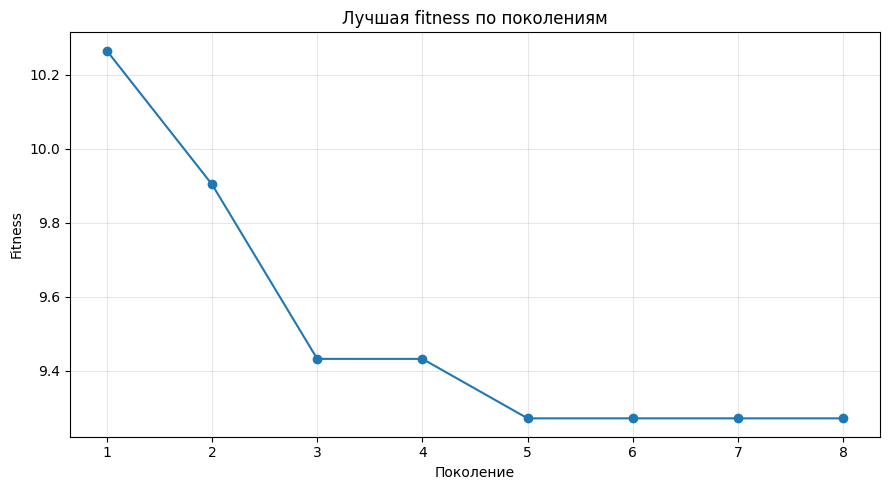

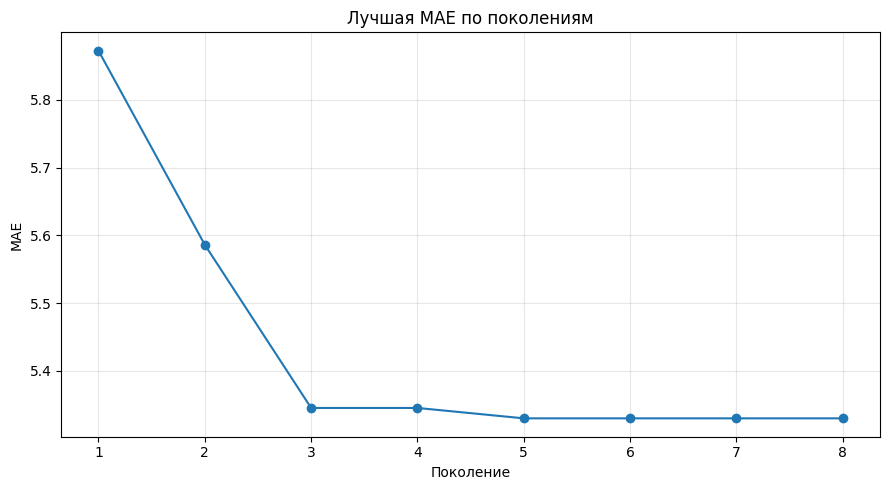

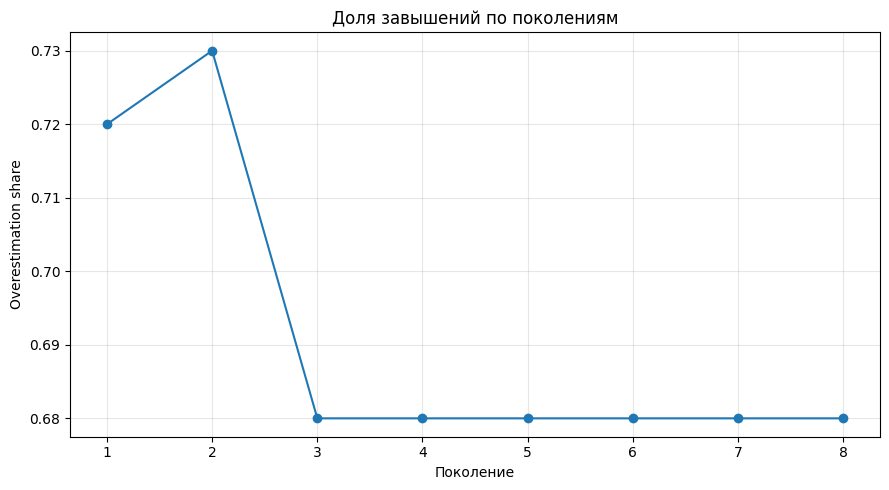

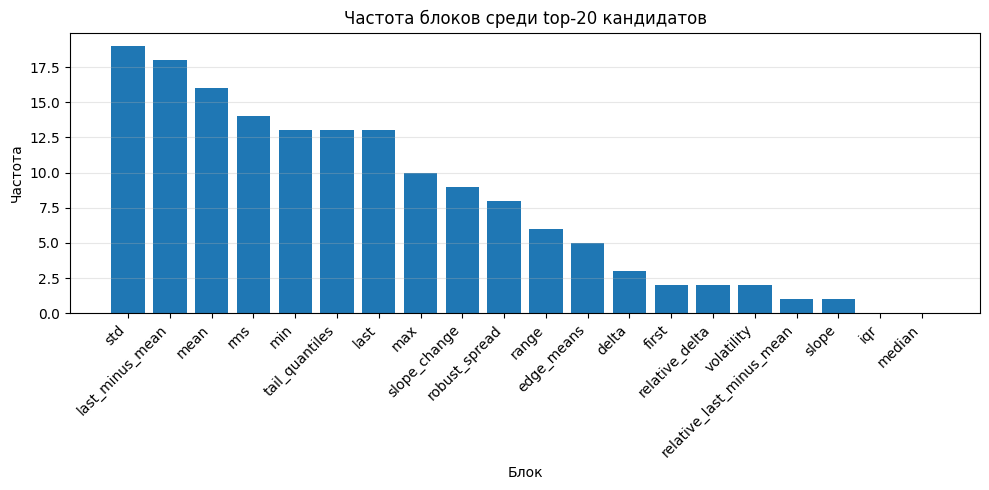

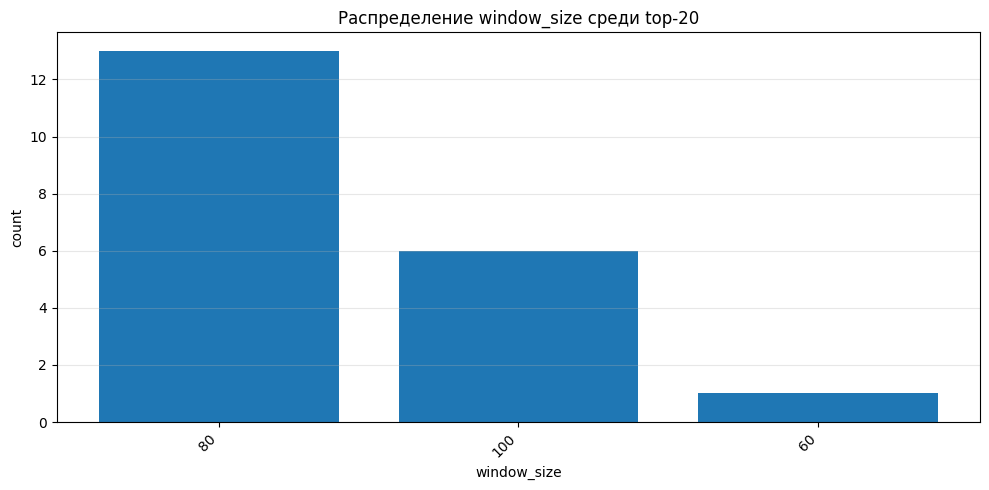

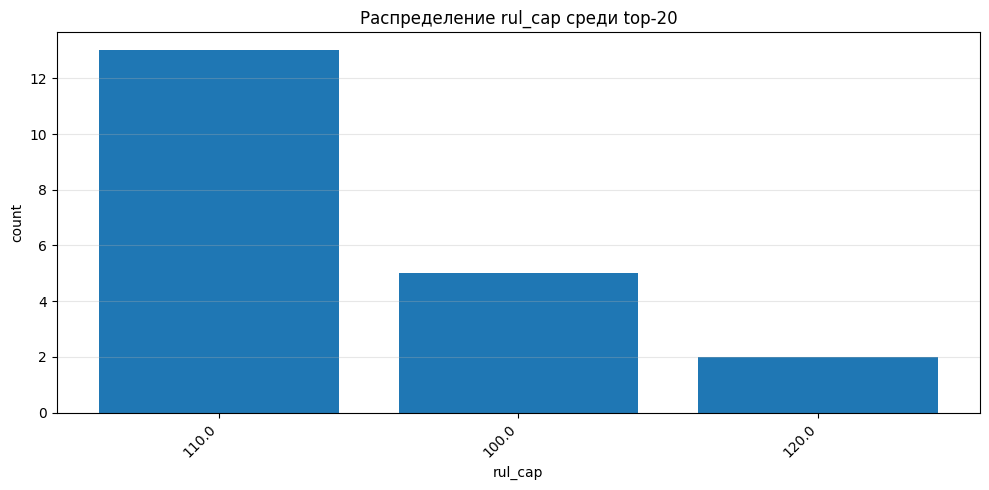

In [34]:
def plot_line(df, x, y, title, xlabel, ylabel):
    plt.figure(figsize=(9, 5))
    plt.plot(df[x], df[y], marker="o")
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_bar(df, x, y, title, xlabel, ylabel):
    plt.figure(figsize=(10, 5))
    plt.bar(df[x].astype(str), df[y])
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_line(generation_summary_df, "generation", "best_fitness", "Лучшая fitness по поколениям", "Поколение", "Fitness")
plot_line(generation_summary_df, "generation", "best_MAE", "Лучшая MAE по поколениям", "Поколение", "MAE")
plot_line(generation_summary_df, "generation", "best_overestimation_share", "Доля завышений по поколениям", "Поколение", "Overestimation share")
plot_bar(block_frequency_df, "block", "count", "Частота блоков среди top-20 кандидатов", "Блок", "Частота")
plot_bar(top_by_fitness_df["window_size"].value_counts().rename_axis("window_size").reset_index(name="count"), "window_size", "count", "Распределение window_size среди top-20", "window_size", "count")
plot_bar(top_by_fitness_df["rul_cap"].fillna("None").value_counts().rename_axis("rul_cap").reset_index(name="count"), "rul_cap", "count", "Распределение rul_cap среди top-20", "rul_cap", "count")


## 11. Выбор финального кандидата

Сравниваем двух кандидатов: лучший по safety fitness и лучший по чистой MAE. Если safety-кандидат проигрывает по MAE не больше 5%, выбираем его. Иначе выбираем MAE-кандидата.

In [35]:
best_safety_row = all_candidate_results_df.sort_values("fitness").iloc[0]
best_mae_row = all_candidate_results_df.sort_values("MAE").iloc[0]

candidate_choice_df = pd.DataFrame([best_safety_row, best_mae_row]).assign(choice_type=["best_safety", "best_mae"])
mae_ratio = best_safety_row["MAE"] / best_mae_row["MAE"]
selected_final_row = best_safety_row if mae_ratio <= 1.05 else best_mae_row
selected_final_candidate = row_to_candidate(selected_final_row)

print(f"selected_candidate_hash={selected_final_row['candidate_hash']}")
print(f"selected_reason={'best_safety' if mae_ratio <= 1.05 else 'best_mae'}")
display(candidate_choice_df)


selected_candidate_hash=f42aa843ddd679988081613314d49fe9
selected_reason=best_safety


,selected_blocks,window_size,rul_cap,rf_max_depth,rf_min_samples_leaf,rf_min_samples_split,rf_max_features,MAE,RMSE,R2,...,near_failure_overestimation_share,warning_zone_MAE,warning_zone_overestimation_share,feature_count,train_seconds,fitness,candidate_hash,status,from_cache,choice_type
0,"[last, last_minus_mean, max, mean, min, rms, r...",80,100.0,NaN,1,4,0.6,5.329962,8.169468,0.948437,...,0.865385,5.663444,0.607143,192,12.74324,9.271687,f42aa843ddd679988081613314d49fe9,ok,False,best_safety
0,"[last, last_minus_mean, max, mean, min, rms, r...",80,100.0,NaN,1,4,0.6,5.329962,8.169468,0.948437,...,0.865385,5.663444,0.607143,192,12.74324,9.271687,f42aa843ddd679988081613314d49fe9,ok,False,best_mae


Выбор делается в пользу safety-кандидата, если он почти не проигрывает по MAE. Это соответствует цели недели: итоговая модель должна быть практичной для RUL-задачи, где опасны не только большие ошибки, но и направление ошибки.

## 12. Финальное обучение на полном train_FD001

Выбранная конфигурация обучается заново на полном train_FD001 уже с более сильным RandomForest. Затем она оценивается на official test set.

In [36]:
def normalize_final_candidate(candidate):
    normalized = candidate.copy()
    normalized["window_size"] = int(normalized["window_size"])
    normalized["rul_cap"] = int_or_none(normalized.get("rul_cap"))
    normalized["rf_max_depth"] = int_or_none(normalized.get("rf_max_depth"))
    normalized["rf_min_samples_leaf"] = int(normalized["rf_min_samples_leaf"])
    normalized["rf_min_samples_split"] = int(normalized["rf_min_samples_split"])
    normalized["rf_max_features"] = none_if_missing(normalized.get("rf_max_features"))
    return normalized


def train_final_model(candidate):
    candidate = normalize_final_candidate(candidate)
    X_train_full, y_train_full, train_meta = build_aggregated_features_for_units(train_df, candidate, mode="train")
    X_test_final, test_unit_ids = build_aggregated_features_for_units(test_df, candidate, mode="official_test")
    params = build_rf_params(candidate, final_rf_base)
    model = RandomForestRegressor(**params)
    start = time.perf_counter()
    model.fit(X_train_full, y_train_full)
    train_seconds = time.perf_counter() - start
    pred = model.predict(X_test_final)
    return model, X_train_full, X_test_final, test_unit_ids, pred, train_seconds


if RUN_OFFICIAL_TEST_AT_END:
    selected_final_candidate = normalize_final_candidate(selected_final_candidate)
    final_model, X_train_final, X_test_final, final_test_unit_ids, original_pred, final_train_seconds = train_final_model(selected_final_candidate)
    original_error_df = build_error_table(y_test_official, original_pred, "week4_final_original", final_test_unit_ids)
    original_metrics = regression_metrics_from_error(original_error_df)
    original_metrics["feature_count"] = int(X_train_final.shape[1])
    original_metrics["train_seconds"] = final_train_seconds
    display(pd.DataFrame([original_metrics]))


,MAE,RMSE,R2,mean_error,overestimation_share,max_overestimation,near_failure_MAE,near_failure_overestimation_share,warning_zone_MAE,warning_zone_overestimation_share,feature_count,train_seconds
0,14.803944,20.375285,0.759593,-9.212493,0.42,29.941554,3.469991,0.72,8.983874,0.764706,192,14.68793


## 13. Консервативная калибровка финальной модели

Shift не участвовал в эволюционном геноме. Теперь он подбирается отдельно как постобработка уже выбранной модели.

In [37]:
def apply_shift_to_error(error_df, shift):
    shifted_df = error_df.copy()
    shifted_df["pred_rul"] = np.maximum(shifted_df["pred_rul"] - shift, 0)
    shifted_df["error"] = shifted_df["pred_rul"] - shifted_df["true_rul"]
    shifted_df["abs_error"] = shifted_df["error"].abs()
    return shifted_df


def evaluate_shift_grid(error_df, shift_grid):
    rows = []
    for shift in shift_grid:
        shifted_df = apply_shift_to_error(error_df, shift)
        metrics = regression_metrics_from_error(shifted_df)
        rows.append({"shift": float(shift), **metrics, "overestimation_count": int((shifted_df["error"] > 0).sum()), "mean_overestimation": float(shifted_df.loc[shifted_df["error"] > 0, "error"].mean()) if (shifted_df["error"] > 0).any() else 0.0})
    return pd.DataFrame(rows)


def select_shift_recommendations(shift_results, original_metrics):
    best_mae = shift_results.sort_values(["MAE", "shift"]).iloc[0]
    best_over = shift_results.sort_values(["overestimation_share", "MAE", "shift"]).iloc[0]
    best_near = shift_results.sort_values(["near_failure_MAE", "MAE", "shift"]).iloc[0]
    candidates = shift_results[(shift_results["MAE"] <= original_metrics["MAE"] * 1.10) & (shift_results["overestimation_share"] < original_metrics["overestimation_share"]) & (shift_results["max_overestimation"] < original_metrics["max_overestimation"])]
    balanced = candidates.sort_values(["MAE", "shift"]).iloc[0] if len(candidates) else best_mae
    return pd.DataFrame([
        {"selection_type": "best_shift_by_MAE", **best_mae.to_dict()},
        {"selection_type": "best_shift_by_overestimation_share", **best_over.to_dict()},
        {"selection_type": "best_shift_by_near_failure_MAE", **best_near.to_dict()},
        {"selection_type": "balanced_recommended_shift", **balanced.to_dict()},
    ])


if RUN_OFFICIAL_TEST_AT_END:
    shift_grid = np.arange(0, 20.5, 0.5)
    final_shift_results_df = evaluate_shift_grid(original_error_df, shift_grid)
    final_shift_recommendation_df = select_shift_recommendations(final_shift_results_df, original_metrics)
    balanced_shift = float(final_shift_recommendation_df.loc[final_shift_recommendation_df["selection_type"] == "balanced_recommended_shift", "shift"].iloc[0])
    calibrated_error_df = apply_shift_to_error(original_error_df, balanced_shift)
    display(final_shift_recommendation_df)


,selection_type,shift,MAE,RMSE,R2,mean_error,overestimation_share,max_overestimation,near_failure_MAE,near_failure_overestimation_share,warning_zone_MAE,warning_zone_overestimation_share,overestimation_count,mean_overestimation
0,best_shift_by_MAE,0.0,14.803944,20.375285,0.759593,-9.212493,0.42,29.941554,3.469991,0.72,8.983874,0.764706,42.0,6.656488
1,best_shift_by_overestimation_share,20.0,28.431057,33.914450,0.333945,-28.137877,0.02,9.941554,13.871979,0.00,15.193975,0.117647,2.0,7.329508
2,best_shift_by_near_failure_MAE,1.0,15.061856,20.846516,0.748344,-10.212493,0.33,28.941554,3.252707,0.52,8.578085,0.647059,33.0,7.347519
3,balanced_recommended_shift,0.5,14.915842,20.606182,0.754113,-9.712493,0.37,29.441554,3.319754,0.60,8.751289,0.705882,37.0,7.031552


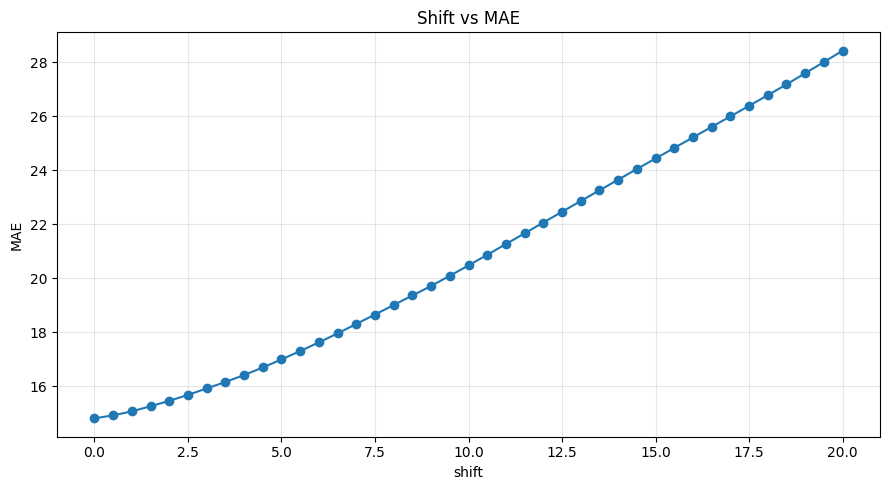

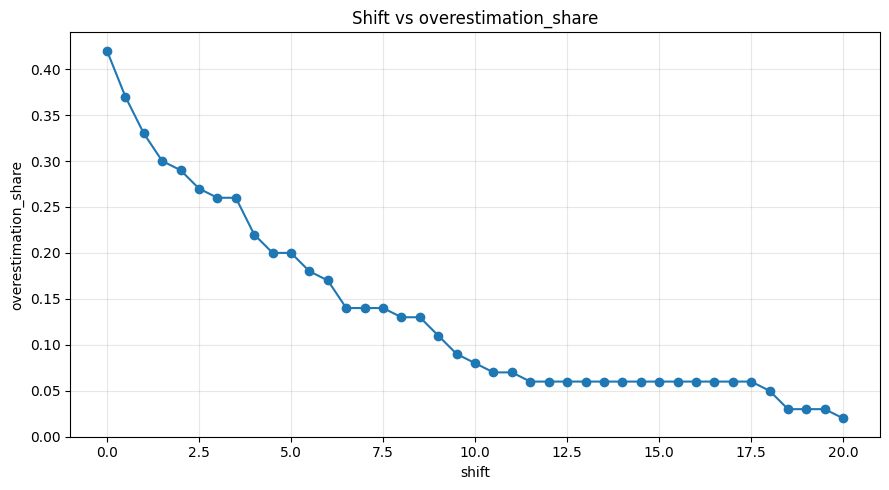

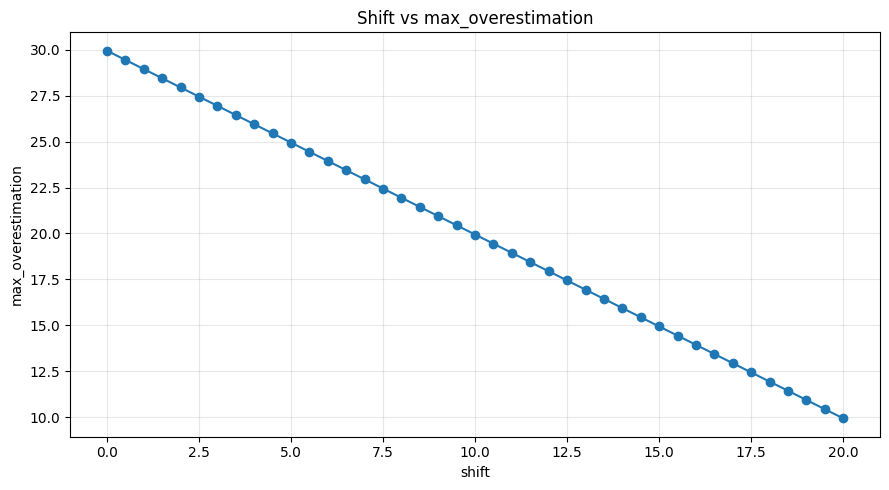

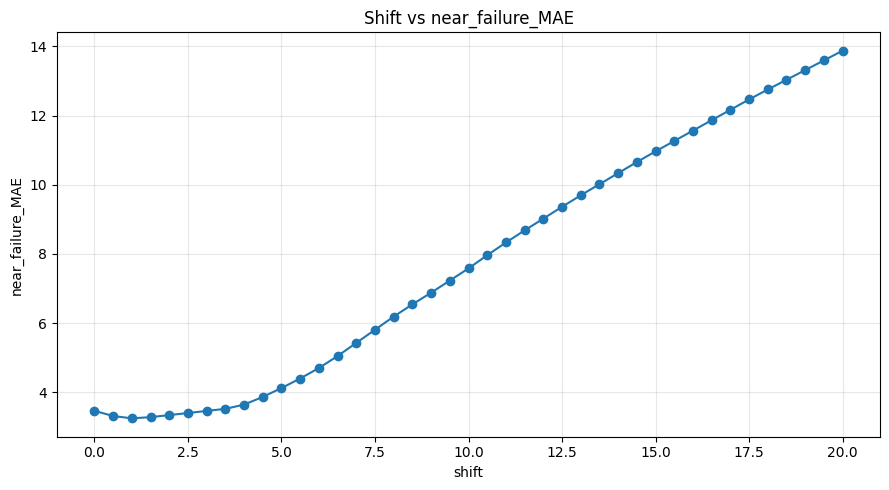

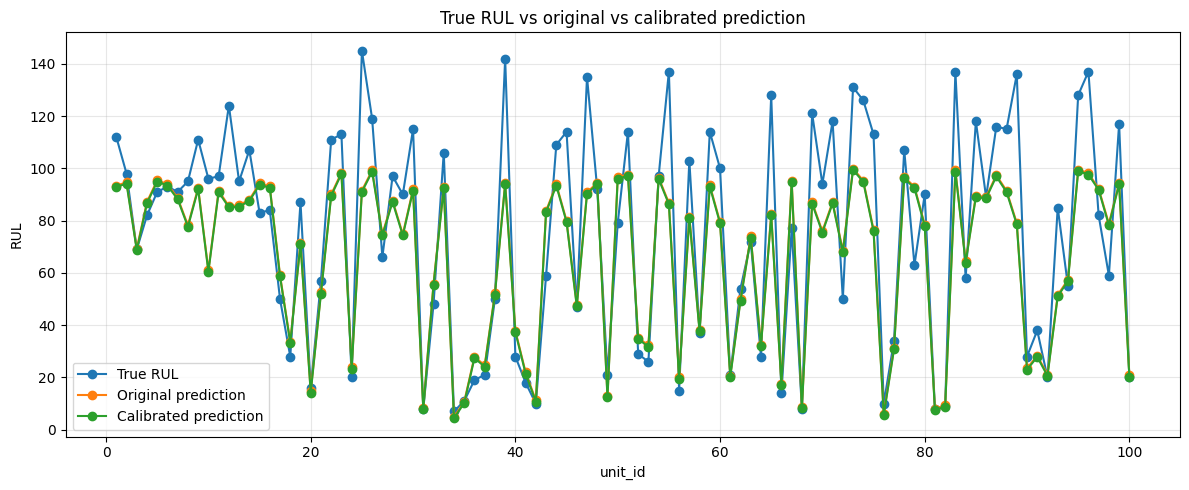

In [38]:
if RUN_OFFICIAL_TEST_AT_END:
    plot_line(final_shift_results_df, "shift", "MAE", "Shift vs MAE", "shift", "MAE")
    plot_line(final_shift_results_df, "shift", "overestimation_share", "Shift vs overestimation_share", "shift", "overestimation_share")
    plot_line(final_shift_results_df, "shift", "max_overestimation", "Shift vs max_overestimation", "shift", "max_overestimation")
    plot_line(final_shift_results_df, "shift", "near_failure_MAE", "Shift vs near_failure_MAE", "shift", "near_failure_MAE")
    plt.figure(figsize=(12, 5))
    plt.plot(original_error_df["id"], original_error_df["true_rul"], marker="o", label="True RUL")
    plt.plot(original_error_df["id"], original_error_df["pred_rul"], marker="o", label="Original prediction")
    plt.plot(calibrated_error_df["id"], calibrated_error_df["pred_rul"], marker="o", label="Calibrated prediction")
    plt.title("True RUL vs original vs calibrated prediction")
    plt.xlabel("unit_id")
    plt.ylabel("RUL")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


## 14. Сравнение с baseline третьей недели

Для сравнения с третьей неделей используется справочная строка с известным ориентиром: агрегатная модель после калибровки давала MAE около 12.5 при shift около 4.5–5.

In [39]:
def load_week3_reference():
    return {
        "model_name": "Week 3 calibrated aggregated RF",
        "feature_search_method": "manual_week3_reference",
        "window_size": 50,
        "rul_cap": None,
        "selected_blocks": "manual_aggregated_blocks",
        "feature_count": 432,
        "train_seconds": np.nan,
        "original_MAE": np.nan,
        "calibrated_MAE": 12.5,
        "original_overestimation_share": np.nan,
        "calibrated_overestimation_share": np.nan,
        "original_near_failure_MAE": np.nan,
        "calibrated_near_failure_MAE": np.nan,
        "recommended_shift": 5.0,
    }

if RUN_OFFICIAL_TEST_AT_END:
    calibrated_metrics = regression_metrics_from_error(calibrated_error_df)
    week4_row = {
        "model_name": "Week 4 evolutionary selected RF",
        "feature_search_method": "evolutionary_search",
        "window_size": selected_final_candidate["window_size"],
        "rul_cap": selected_final_candidate["rul_cap"],
        "selected_blocks": json.dumps(selected_final_candidate["selected_blocks"], ensure_ascii=False),
        "feature_count": X_train_final.shape[1],
        "train_seconds": final_train_seconds,
        "original_MAE": original_metrics["MAE"],
        "calibrated_MAE": calibrated_metrics["MAE"],
        "original_overestimation_share": original_metrics["overestimation_share"],
        "calibrated_overestimation_share": calibrated_metrics["overestimation_share"],
        "original_near_failure_MAE": original_metrics["near_failure_MAE"],
        "calibrated_near_failure_MAE": calibrated_metrics["near_failure_MAE"],
        "recommended_shift": balanced_shift,
    }
    week4_vs_week3_df = pd.DataFrame([load_week3_reference(), week4_row])
    display(week4_vs_week3_df)


,model_name,feature_search_method,window_size,rul_cap,selected_blocks,feature_count,train_seconds,original_MAE,calibrated_MAE,original_overestimation_share,calibrated_overestimation_share,original_near_failure_MAE,calibrated_near_failure_MAE,recommended_shift
0,Week 3 calibrated aggregated RF,manual_week3_reference,50,NaN,manual_aggregated_blocks,432,NaN,NaN,12.500000,NaN,NaN,NaN,NaN,5.0
1,Week 4 evolutionary selected RF,evolutionary_search,80,100.0,"[""last"", ""last_minus_mean"", ""max"", ""mean"", ""mi...",192,14.68793,14.803944,14.915842,0.42,0.37,3.469991,3.319754,0.5


## 15. Итоговые выводы

На этой неделе мы перешли от ручного выбора агрегатных признаков к автоматическому поиску признакового пространства. Каждый pipeline кодировался как набор блоков признаков, размер окна, вариант capped RUL и параметры RandomForest. Для поиска использовался эволюционный алгоритм: лучшие конфигурации сохранялись, скрещивались и мутировали, поэтому мы проверяли не все возможные комбинации, а постепенно двигались к более сильным вариантам.

Важный момент: conservative shift не подбирался внутри эволюционного алгоритма. Сначала выбиралась сама модель, затем уже готовые предсказания калибровались отдельным постпроцессингом. Это делает эксперимент более аккуратным и показывает, что улучшение связано не только с подбором сдвига.

Так как задача связана с остаточным ресурсом авиационных двигателей, итоговый выбор модели нельзя делать только по MAE. Завышение RUL является safety-critical ошибкой, поэтому мы дополнительно учитывали overestimation_share, max_overestimation и качество в near-failure зоне.

Итоговая модель должна интерпретироваться как практический safety-oriented RUL pipeline, а не просто как модель с минимальной средней ошибкой.

## 16. Runtime safeguards

Эволюционный поиск может быть долгим, поэтому в начале блокнота есть `FAST_MODE`. Если нужно быстро проверить работоспособность, можно поставить `FAST_MODE = True`: размер популяции, число поколений и число деревьев во время поиска уменьшатся. Также работает кэширование кандидатов, поэтому уже посчитанные конфигурации не пересчитываются.

In [40]:
runtime_safeguards_df = pd.DataFrame({
    "setting": ["FAST_MODE", "USE_CACHE", "PROGRESS_EVERY_CANDIDATE", "population_size", "generations", "search_n_estimators"],
    "value": [FAST_MODE, USE_CACHE, PROGRESS_EVERY_CANDIDATE, population_size, generations, search_rf_base["n_estimators"]],
})
runtime_safeguards_df


,setting,value
0,FAST_MODE,False
1,USE_CACHE,True
2,PROGRESS_EVERY_CANDIDATE,True
3,population_size,18
4,generations,8
5,search_n_estimators,180


## 17. Финальная сводка результатов

In [41]:
summary_tables = {
    "generation_summary_df": generation_summary_df,
    "all_candidate_results_df": all_candidate_results_df,
    "best_candidates_df": best_candidates_df,
    "top_by_fitness_df": top_by_fitness_df,
    "top_by_mae_df": top_by_mae_df,
    "block_frequency_df": block_frequency_df,
}

if RUN_OFFICIAL_TEST_AT_END:
    summary_tables.update({
        "final_shift_results_df": final_shift_results_df,
        "final_shift_recommendation_df": final_shift_recommendation_df,
        "week4_vs_week3_df": week4_vs_week3_df,
    })

pd.DataFrame({
    "table_name": list(summary_tables.keys()),
    "rows": [len(table) for table in summary_tables.values()],
    "columns": [len(table.columns) for table in summary_tables.values()],
})


,table_name,rows,columns
0,generation_summary_df,8,9
1,all_candidate_results_df,102,23
2,best_candidates_df,30,23
3,top_by_fitness_df,20,23
4,top_by_mae_df,20,23
5,block_frequency_df,20,2
6,final_shift_results_df,41,13
7,final_shift_recommendation_df,4,14
8,week4_vs_week3_df,2,14
